# Credit Card Fraud Detection — Capstone Project

This capstone project brings together everything learned across the Classical ML phase: handling extreme class imbalance with SMOTE, building a proper preprocessing+modeling pipeline, and comparing four different algorithms (Logistic Regression, Decision Tree, Random Forest, XGBoost) on a real, large-scale dataset.

**Dataset:** Credit Card Fraud Detection (284,807 transactions, 0.17% fraud rate)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

## 1. Data Loading and Initial Exploration

In [4]:
df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')
print(df.shape)
print(df.info())
print(df["Class"].value_counts())

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

## 2. Exploratory Data Analysis

Checking the distribution of transaction amounts and comparing fraud vs. normal transactions.

In [5]:
print(df["Amount"].describe())
print(df["Time"].describe())

print(df.groupby("Class")["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


### Visualizing the Extreme Class Imbalance

A log scale is used here because on a normal scale, the fraud class (492 cases out of 284,807) would be nearly invisible.

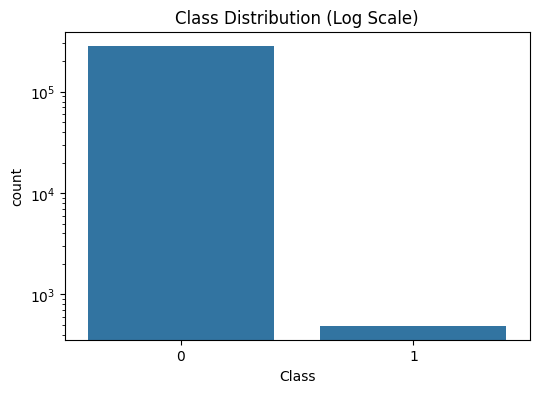

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.yscale("log")
plt.title("Class Distribution (Log Scale)")
plt.show()

## 3. Baseline Model (No Imbalance Handling)

Training a Logistic Regression model with no special handling, to establish a reference point before applying SMOTE.

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962

AUC Score: 0.9513502678786764


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Adding Feature Scaling

A convergence warning on the unscaled model indicated that Time and Amount, being on very different scales from the PCA-transformed features, were affecting optimization. Scaling resolves this and slightly improves the AUC, though it changes the precision/recall trade-off at the default threshold.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

AUC Score: 0.9605494455801453


## 4. Applying SMOTE

### Experiment 1: Full Balancing (50/50)

Testing what happens when SMOTE fully balances the classes. This is included to show why this approach was rejected.

In [13]:
print("Before SMOTE:", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [14]:
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test_scaled)
y_pred_proba_smote = model_smote.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_smote))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC Score: 0.9708434302252134


**Result:** Recall improved significantly (to 0.92), but precision collapsed to 0.06 — the model became overly sensitive, flagging far too many normal transactions as fraud. A more moderate sampling ratio was tested next.

### Experiment 2: Partial Balancing (10%)

In [15]:
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_smote2, y_train_smote2 = smote.fit_resample(X_train_scaled, y_train)

print(y_train_smote2.value_counts())

model_smote2 = LogisticRegression(max_iter=1000)
model_smote2.fit(X_train_smote2, y_train_smote2)

y_pred_smote2 = model_smote2.predict(X_test_scaled)
print(classification_report(y_test, y_pred_smote2))

Class
0    227451
1     22745
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.35      0.89      0.50        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.75     56962
weighted avg       1.00      1.00      1.00     56962



### Systematically Tuning the SMOTE Ratio

Rather than guessing a sampling_strategy value, several ratios were tested directly to find the best precision/recall balance.

In [17]:
strategies = [0.05, 0.1, 0.15, 0.2, 0.3]

for strategy in strategies:
    smote = SMOTE(sampling_strategy=strategy, random_state=42)
    X_temp, y_temp = smote.fit_resample(X_train_scaled, y_train)

    temp_model = LogisticRegression(max_iter=1000)
    temp_model.fit(X_temp, y_temp)

    temp_pred = temp_model.predict(X_test_scaled)

    precision = precision_score(y_test, temp_pred)
    recall = recall_score(y_test, temp_pred)
    f1 = f1_score(y_test, temp_pred)

    print(f"Strategy={strategy}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

Strategy=0.05: Precision=0.570, Recall=0.878, F1=0.691
Strategy=0.1: Precision=0.352, Recall=0.888, F1=0.504
Strategy=0.15: Precision=0.251, Recall=0.888, F1=0.392
Strategy=0.2: Precision=0.207, Recall=0.888, F1=0.336
Strategy=0.3: Precision=0.162, Recall=0.898, F1=0.274


## 5. Building the Pipeline and Comparing Models

The best SMOTE ratio found above (0.05) is now used inside a proper imbalanced-learn Pipeline, which bundles scaling, SMOTE, and the model into a single object. This pipeline automatically applies scaling correctly and ensures SMOTE is only ever applied to training data, never at prediction time.

Four algorithms are compared under identical conditions: Logistic Regression, Decision Tree, Random Forest, and XGBoost.

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.05, random_state=42)),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_pred_proba)
    }
    print(f"\n{name}: {results[name]}")


Logistic Regression: {'Precision': 0.5695364238410596, 'Recall': 0.8775510204081632, 'F1': 0.6907630522088354, 'AUC': np.float64(0.96744344544233)}

Decision Tree: {'Precision': 0.5753424657534246, 'Recall': 0.8571428571428571, 'F1': 0.6885245901639344, 'AUC': np.float64(0.944831222795815)}

Random Forest: {'Precision': 0.7610619469026548, 'Recall': 0.8775510204081632, 'F1': 0.8151658767772512, 'AUC': np.float64(0.9709417672527649)}

XGBoost: {'Precision': 0.6212121212121212, 'Recall': 0.8367346938775511, 'F1': 0.7130434782608696, 'AUC': np.float64(0.9736164267338899)}


### Result Summary

| Model | Precision | Recall | F1-Score | AUC |
|---|---|---|---|---|
| Logistic Regression | 0.570 | 0.878 | 0.691 | 0.967 |
| Decision Tree | 0.575 | 0.857 | 0.689 | 0.945 |
| **Random Forest** | **0.761** | 0.878 | **0.815** | 0.971 |
| XGBoost | 0.621 | 0.837 | 0.713 | 0.974 |

**Random Forest was selected as the best model.** While XGBoost had a marginally higher AUC, Random Forest had a substantially better F1-score and precision, with comparable recall — making it the more practically useful model, since it produces far fewer false alarms without meaningfully sacrificing fraud detection.

## 6. Saving Trained Pipelines for Prediction

In [21]:
trained_pipelines = {}

for name, model in models.items():
    pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=0.05, random_state=42)),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

print("All 4 pipelines trained and stored")

All 4 pipelines trained and stored


## 7. Prediction Function

A function that takes raw transaction details and returns predictions from all four trained pipelines, for direct comparison.

In [22]:
def predict_fraud_all_models(time, amount, v_features, threshold=0.5):

    data = {"Time": time, "Amount": amount}
    data.update(v_features)

    input_df = pd.DataFrame([data])
    input_df = input_df[X_train.columns]

    print(f"\n Prediction for Transaction (Amount=${amount}) ")
    for name, pipeline in trained_pipelines.items():
        probability = pipeline.predict_proba(input_df)[:, 1][0]
        prediction = "FRAUD" if probability >= threshold else "Normal"
        print(f"{name}: Probability={probability:.2%} | Prediction={prediction}")

### Testing on a Real Fraud Case

A genuine fraud transaction from the test set is used here (rather than a manually invented one, since V1-V28 are anonymized PCA features with no interpretable real-world values).

In [23]:
fraud_sample = X_test[y_test == 1].iloc[0]
v_features = {f"V{i}": fraud_sample[f"V{i}"] for i in range(1, 29)}

predict_fraud_all_models(
    time=fraud_sample["Time"],
    amount=fraud_sample["Amount"],
    v_features=v_features
)


 Prediction for Transaction (Amount=$0.01) 
Logistic Regression: Probability=99.90% | Prediction=FRAUD
Decision Tree: Probability=99.53% | Prediction=FRAUD
Random Forest: Probability=99.54% | Prediction=FRAUD
XGBoost: Probability=99.60% | Prediction=FRAUD


<Figure size 1000x600 with 0 Axes>

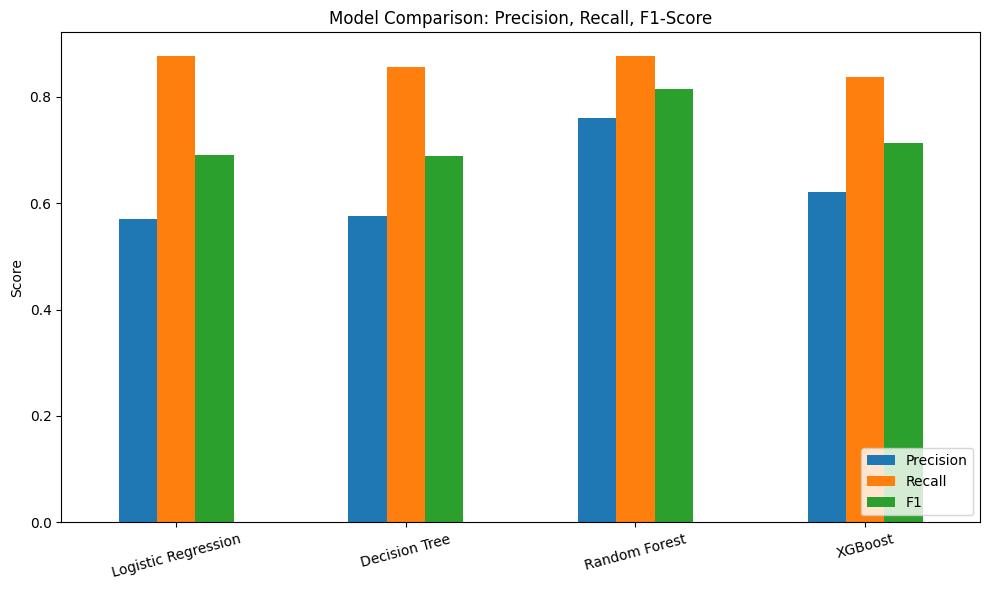

In [24]:
model_names = list(results.keys())
metrics_df = pd.DataFrame(results).T

plt.figure(figsize=(10,6))
metrics_df[["Precision", "Recall", "F1"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison: Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()